# **PyMC Price Target Model**

## Price Target Achievement — Hierarchical Student-t Regression

Schema-aligned with:
- MV: `pml.mv_pymc_price_target`
- Catalogue: `SELECT * FROM pml.vw_pymc_feature_catalogue WHERE model_target = 'price_target'`

Likelihood:
- `observed_target_pct ~ StudentT(ν, μ_isin, σ_isin)` (heavy-tailed analyst noise)
- `μ_isin = α_sector[sector] + X_std · β`
- `σ_isin = σ_base / sqrt(n_analysts)` (precision-weighted by analyst count)


In [1]:
%%sql
SELECT * FROM pml.mv_pymc_price_target

,isin,ticker,region,country,trading_country,exchange,unit,style_class,size_class,sector,...,feat_implied_upside,feat_target_range_width,feat_pt_momentum_3m,feat_coverage_change_3m,feat_target_dispersion_cv,feat_52w_range_position,feat_pe_ntm,feat_ev_ebitda_ntm,feat_vol_3m,feat_analyst_rating
0,US02079K3059,GOOGL,United States and Canada,US,US,NasdaqGS,USD,Core,Large Cap,Communication Services,...,0.120494,-3.708562,0.141310,-0.070175,0.079015,0.896184,30.5,19.1,33.84,4.57
1,US7311054099,PSNY,Europe,SE,US,NasdaqGM,USD,Core,Small Cap,Consumer Discretionary,...,-0.213483,-0.689687,-0.222222,0.000000,0.142857,0.340357,NaN,NaN,77.58,2.00
2,US49177J1025,KVUE,United States and Canada,US,US,NYSE,USD,Value,Large Cap,Consumer Staples,...,0.099430,10.641791,-0.020019,-0.083333,0.076926,0.424179,14.5,10.8,20.25,3.08
3,IL0002810146,ICL,Africa / Middle East,IL,US,NYSE,USD,Value,Mid Cap,Materials,...,-0.017028,-1.509445,0.051760,0.000000,0.092157,0.695596,15.1,6.8,44.87,3.00
4,US0378331005,AAPL,United States and Canada,US,US,NasdaqGS,USD,Core,Large Cap,Information Technology,...,-0.000562,-1.972021,0.053336,0.023810,0.119749,0.978265,33.9,25.7,21.83,4.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6607,NGCONOIL0003,CONOIL,Africa / Middle East,NG,NG,NGSE,NGN,Core,Small Cap,Energy,...,1.110825,0.000000,0.000000,0.000000,0.000000,0.160132,NaN,NaN,110.12,NaN
6608,OM0000002168,AACT,Africa / Middle East,OM,OM,MSM,OMR,Value,Small Cap,Industrials,...,0.285714,1.555694,0.074627,0.000000,0.097222,0.312039,19.8,8.8,38.08,4.33
6609,TRAGOODY91E9,GOODY,Africa / Middle East,TR,TR,IBSE,TRY,Core,Small Cap,Consumer Discretionary,...,0.149282,0.000000,0.000000,0.000000,0.000000,0.373692,NaN,NaN,41.37,3.00
6610,MA0000010936,ALM,Africa / Middle East,MA,MA,CBSE,MAD,Core,Small Cap,Industrials,...,0.188770,0.000000,0.181818,0.000000,0.000000,0.636616,14.0,7.9,29.19,4.00


In [2]:
%%sql
SELECT *
FROM pml.vw_pymc_feature_catalogue
WHERE model_target = 'price_target'
ORDER BY pymc_role, feature_role, feature_alias

,model_target,pymc_role,column_name,category,feature_role,feature_alias,data_type,description
0,price_target,constant_data,num_hold_ratings,analyst_ratings,count,feat_holds,integer,Number of hold ratings
1,price_target,constant_data,num_no_opinion_ratings,analyst_ratings,count,feat_no_opinion,integer,Number of no-opinion ratings
2,price_target,constant_data,price_target_num,analyst_targets,count,n_analysts,double precision,Number of analyst price targets
3,price_target,constant_data,num_buys_ratings,analyst_ratings,count,num_buys_ratings,integer,Number of buy ratings
4,price_target,constant_data,num_sell_ratings,analyst_ratings,count,num_sell_ratings,integer,Number of sell ratings
...,...,...,...,...,...,...,...,...
123,price_target,observed,target_pct_avg,analyst_targets,target,observed_target_pct,double precision,Implied upside vs. average analyst target (%)
124,price_target,observed,target_pct_med,analyst_targets,target,observed_target_pct_med,double precision,Implied upside vs. median analyst target (%)
125,price_target,observed,price_target_high,analyst_targets,target,price_target_high,double precision,High analyst price target
126,price_target,observed,price_target_low,analyst_targets,target,price_target_low,double precision,Low analyst price target


## 1. Notebook Setup & Imports

Shared imports for EDA, schema-aligned summary statistics, PyMC modelling, and prior/posterior predictive diagnostics. The `price_target_df` and `feature_catalogue` DataFrames produced by the two `%%sql` cells above are reused throughout.


In [3]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import arviz as az
except ImportError:  # ArviZ 1.0 split packages
    import arviz_base as az  # type: ignore

import pymc as pm
import pytensor.tensor as pt

warnings.filterwarnings('ignore', category=FutureWarning)
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

# --- Dark theme for all plots ------------------------------------------------
# Matplotlib dark background + seaborn dark grid keep ArviZ / pandas / seaborn
# figures visually consistent. Try ArviZ's bundled dark stylesheet first; if
# unavailable, fall back to matplotlib's built-in 'dark_background'.
plt.style.use('dark_background')
try:
    az.style.use('arviz-darkgrid')
except (OSError, ValueError, AttributeError):
    pass
sns.set_theme(style='darkgrid', context='notebook',
              rc={
                  'figure.facecolor': '#1e1e1e',
                  'axes.facecolor': '#2a2a2a',
                  'savefig.facecolor': '#1e1e1e',
                  'axes.edgecolor': '#cccccc',
                  'axes.labelcolor': '#e6e6e6',
                  'xtick.color': '#e6e6e6',
                  'ytick.color': '#e6e6e6',
                  'text.color': '#e6e6e6',
                  'grid.color': '#555555',
              })
plt.rcParams['figure.dpi'] = 110

print(f'price_target_df : {price_target_df.shape}')
print(f'feature_catalogue: {feature_catalogue.shape}  (model_target=price_target)')
assert (feature_catalogue['model_target'] == 'price_target').all(), \
    "feature_catalogue must be pre-filtered to model_target='price_target'"


price_target_df : (6612, 29)
feature_catalogue: (128, 8)  (model_target=price_target)


C:\Users\markm\PML_Finance_Project\.venv\Lib\site-packages\pytensor\configparser.py:309: UserWarning: PyTensor does not recognise this flag: device
  warnings.warn(f"PyTensor does not recognise this flag: {key}")


## 2. Exploratory Data Analysis (EDA) — `price_target_df`

Schema-aligned EDA driven by `feature_catalogue` (the `vw_pymc_feature_catalogue` view for `model_target = 'price_target'`). We split columns by `pymc_role` (`response`, `mutable_predictor`, `coord`) and `feature_role` to drive shape, missingness, and distribution checks.


In [4]:
# Map feature_catalogue -> columns actually present in price_target_df
catalogue = feature_catalogue.copy()
catalogue['present'] = catalogue['feature_alias'].isin(price_target_df.columns)

role_summary = (
    catalogue.groupby(['pymc_role', 'feature_role'])['present']
    .agg(n_columns='size', n_present='sum')
    .reset_index()
)
role_summary


,pymc_role,feature_role,n_columns,n_present
0,constant_data,count,7,3
1,coord,categorical,9,9
2,derived_input,historical,75,2
3,mutable_predictor,predictor,27,4
4,mutable_predictor,score,1,1
5,observed,target,9,4


In [5]:
# Resolve column groups by pymc_role
present = catalogue.loc[catalogue['present']]
PREDICTOR_COLS = present.loc[present['pymc_role'] == 'mutable_predictor', 'feature_alias'].tolist()
COORD_COLS = present.loc[present['pymc_role'] == 'coord', 'feature_alias'].tolist()
RESPONSE_COLS = present.loc[present['pymc_role'].isin(['response', 'observed']), 'feature_alias'].tolist()

# Canonical fallbacks for the price-target MV
for col in ('observed_target_pct', 'observed_target_pct_med', 'n_analysts', 'last_price'):
    if col in price_target_df.columns and col not in RESPONSE_COLS + COORD_COLS:
        if col.startswith('observed_'):
            RESPONSE_COLS.append(col)

# Classification coords (all 9 from the new MV)
CLASSIFICATION_COORDS = [c for c in (
    'isin', 'ticker', 'region', 'country', 'trading_country',
    'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry'
) if c in price_target_df.columns]

# Build source-column -> MV alias mapping from the catalogue. The catalogue
# view now exposes the per-model `feature_alias` populated by
# pml.pml_df_feature_alias, so downstream code can address columns by their
# materialized-view alias (e.g. feat_eps_fy1e, observed_target_pct, n_beats,
# region/country/sector classification coords).
if 'feature_alias' in catalogue.columns:
    ALIAS_MAP = (
        present.dropna(subset=['feature_alias'])
        .set_index('column_name')['feature_alias']
        .to_dict()
    )
else:
    ALIAS_MAP = {c: c for c in present['column_name']}

print(f'#predictors : {len(PREDICTOR_COLS)}')
print(f'#coords     : {len(COORD_COLS)}  -> {COORD_COLS}')
print(f'#response   : {len(RESPONSE_COLS)} -> {RESPONSE_COLS}')
print(f'#classification : {len(CLASSIFICATION_COORDS)} -> {CLASSIFICATION_COORDS}')
print(f'#aliases    : {len(ALIAS_MAP)} (source_column -> mv_alias)')


#predictors : 5
#coords     : 9  -> ['country', 'exchange', 'industry', 'region', 'sector', 'size_class', 'style_class', 'trading_country', 'unit']
#response   : 4 -> ['feat_implied_upside', 'feat_target_dispersion_cv', 'observed_target_pct', 'observed_target_pct_med']
#classification : 11 -> ['isin', 'ticker', 'region', 'country', 'trading_country', 'exchange', 'unit', 'style_class', 'size_class', 'sector', 'industry']
#aliases    : 23 (source_column -> mv_alias)


In [6]:
# 2.1 Shape, dtypes, missingness overview
missing = price_target_df.isna().mean().sort_values(ascending=False)
eda_overview = pd.DataFrame({
    'dtype': price_target_df.dtypes.astype(str),
    'missing_pct': missing.round(4),
    'n_unique': price_target_df.nunique(dropna=True),
})
eda_overview.head(20)


,dtype,missing_pct,n_unique
country,str,0.0000,89
exchange,str,0.0000,87
feat_52w_range_position,float64,0.0005,6527
feat_analyst_rating,float64,0.0127,262
feat_conviction_ratio,float64,0.0127,186
feat_coverage_change_3m,float64,0.0162,189
feat_ev_ebitda_ntm,float64,0.0957,640
feat_holds,int64,0.0000,26
feat_implied_upside,float64,0.0000,6531
feat_net_buy_sentiment,int64,0.0000,59


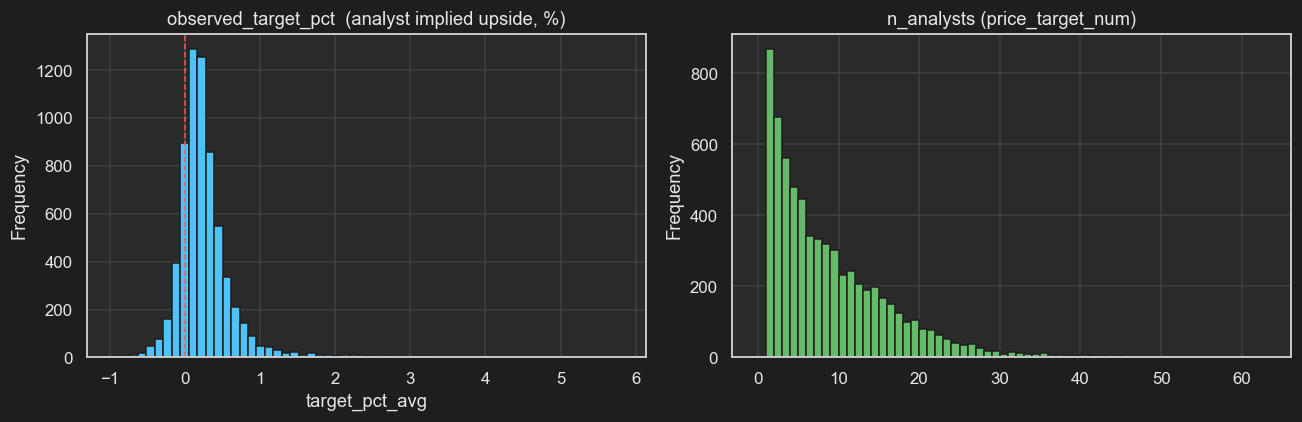

In [7]:
# 2.2 Response distribution: observed_target_pct + n_analysts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

price_target_df['observed_target_pct'].dropna().plot.hist(
    bins=60, ax=axes[0], edgecolor='#1e1e1e', color='#4FC3F7'
)
axes[0].axvline(0, color='#FF5252', ls='--', lw=1)
axes[0].set_title('observed_target_pct  (analyst implied upside, %)')
axes[0].set_xlabel('target_pct_avg')

n_analysts_s = price_target_df['n_analysts'].dropna().astype(int)
n_analysts_s.plot.hist(bins=range(0, int(n_analysts_s.max()) + 2),
                       ax=axes[1], edgecolor='#1e1e1e', color='#66BB6A')
axes[1].set_title('n_analysts (price_target_num)')
plt.tight_layout();
plt.show()


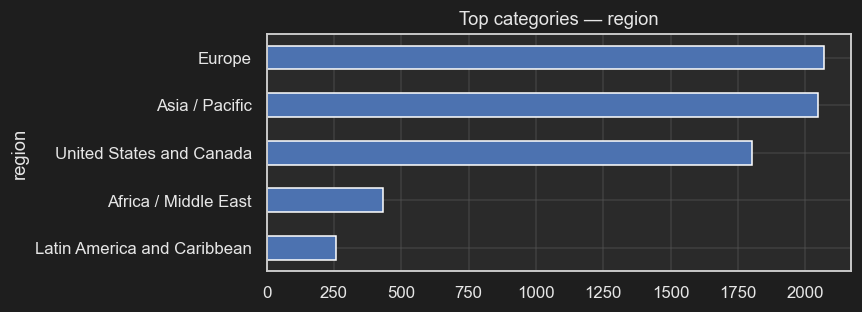

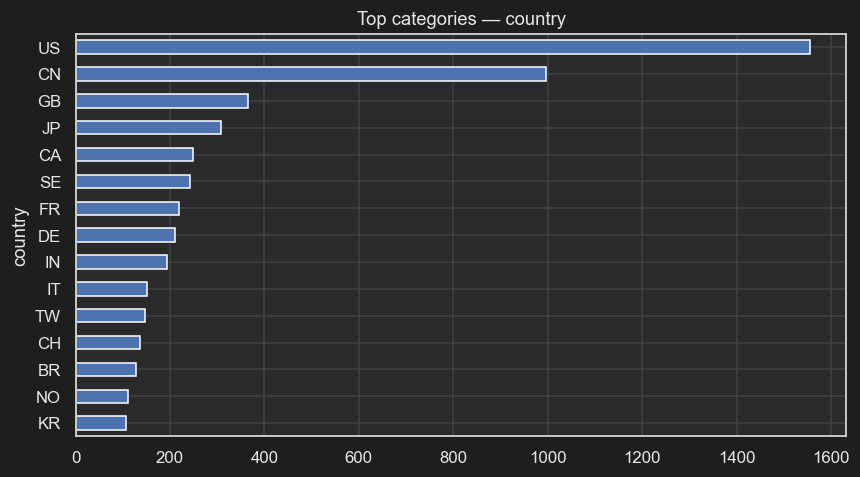

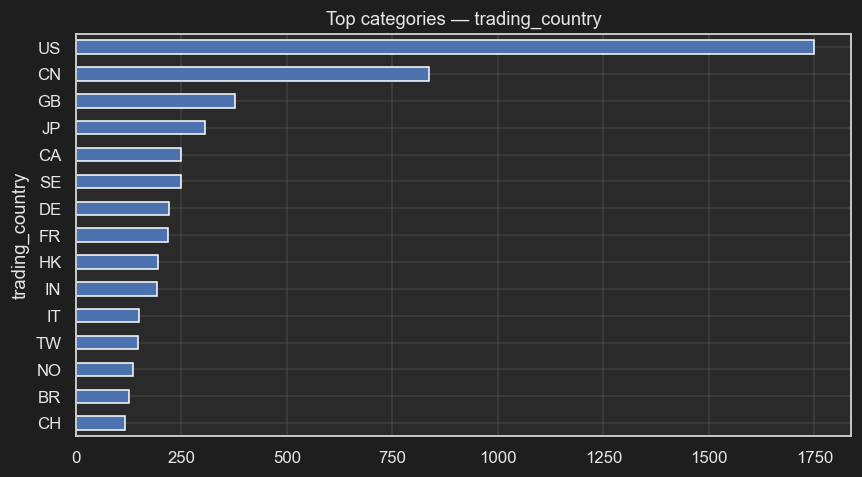

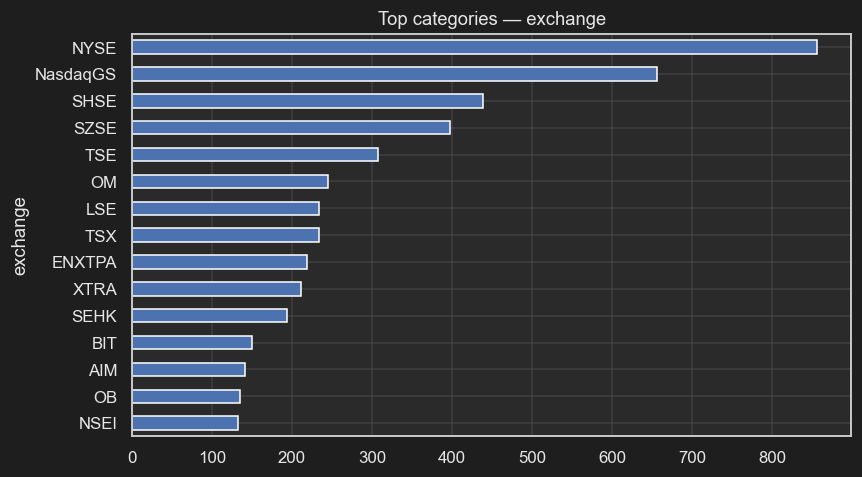

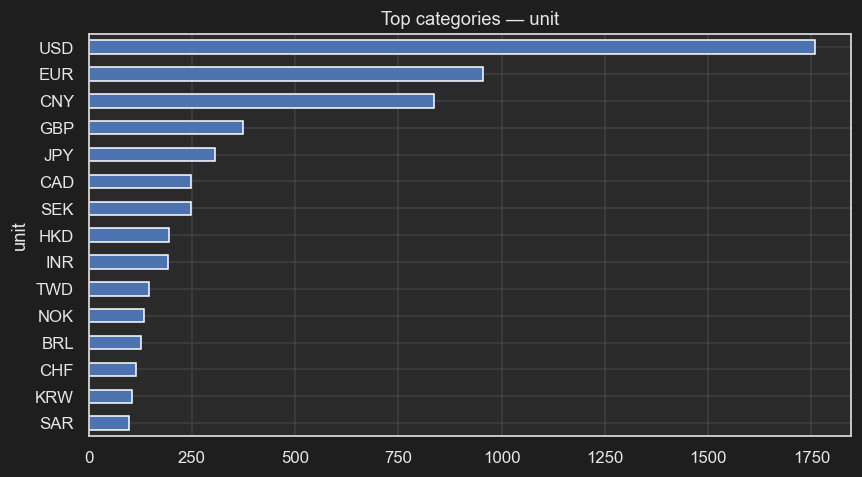

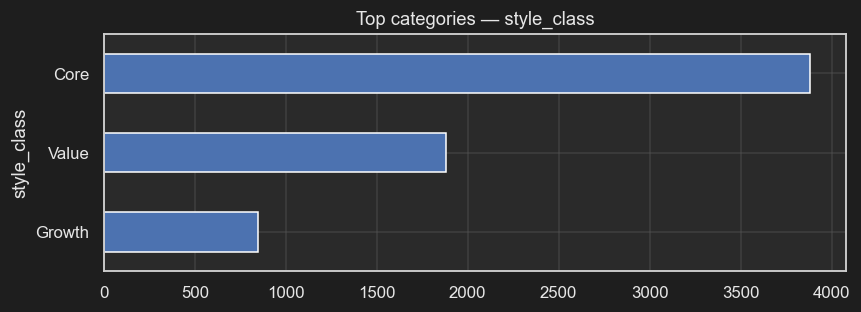

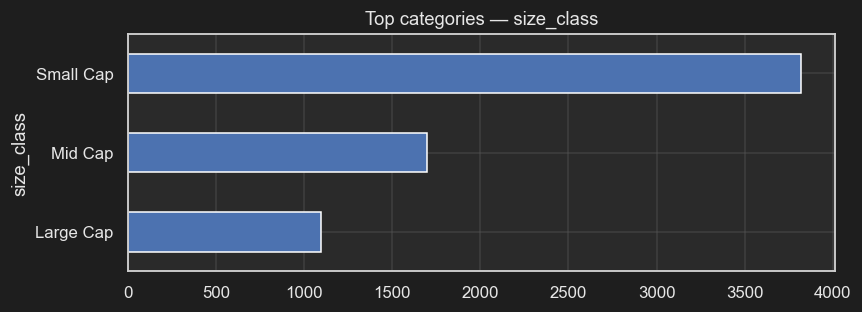

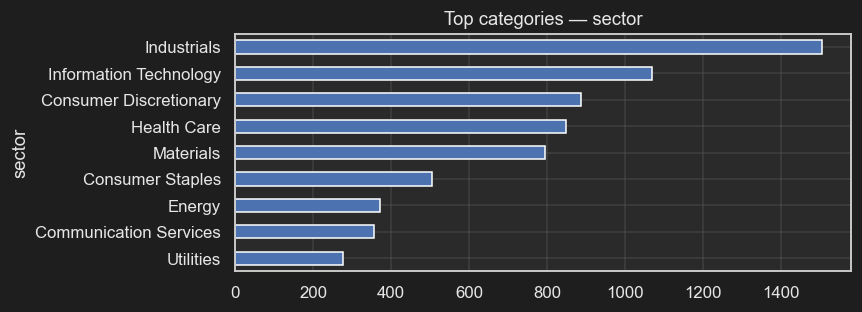

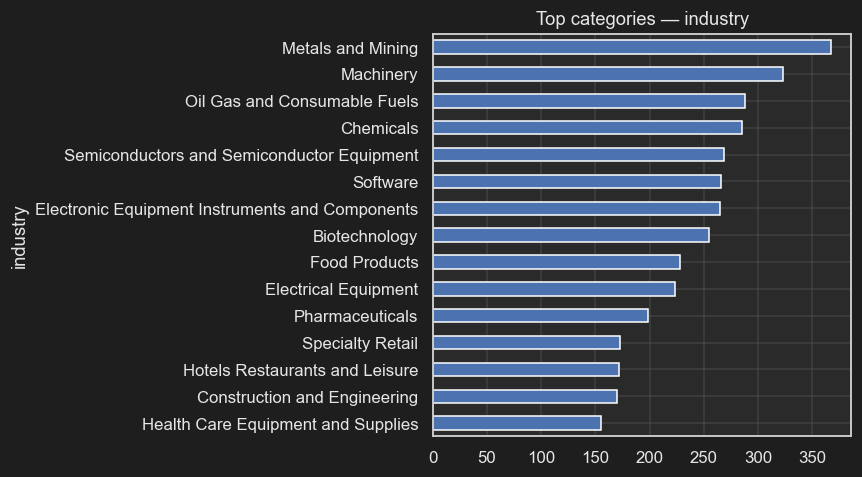

In [8]:
# 2.3 Classification coord cardinality (region / country / sector / industry / ...)
for col in CLASSIFICATION_COORDS:
    if col in ('isin', 'ticker'):
        continue
    counts = price_target_df[col].value_counts(dropna=False).head(15)
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(counts))))
    counts.sort_values().plot.barh(ax=ax)
    ax.set_title(f'Top categories — {col}')
    plt.tight_layout();
    plt.show()


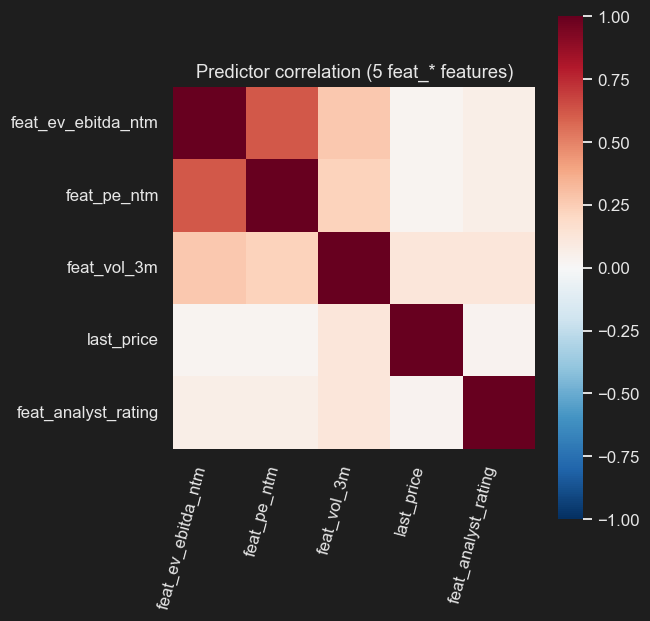

In [9]:
# 2.4 Predictor correlation heatmap (numeric predictors only)
num_predictors = [c for c in PREDICTOR_COLS
                  if pd.api.types.is_numeric_dtype(price_target_df[c])]

if len(num_predictors) < 2:
    print(f'⚠️ Predictor correlation heatmap skipped — '
          f'only {len(num_predictors)} numeric predictor(s) available '
          f'(need ≥ 2). Check that `feature_catalogue` tags '
          f'`mutable_predictor` columns that actually exist in `price_target_df`.')
else:
    corr = price_target_df[num_predictors].corr(numeric_only=True)
    side = min(14, 0.4 * len(num_predictors) + 4)
    fig, ax = plt.subplots(figsize=(side, side))
    # Only render tick labels when the matrix is small enough to read them.
    show_labels = len(num_predictors) <= 30
    sns.heatmap(
        corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        xticklabels=show_labels, yticklabels=show_labels,
        square=True, ax=ax,
    )
    if show_labels:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')
    ax.set_title(f'Predictor correlation ({len(num_predictors)} feat_* features)')
    plt.tight_layout()
    plt.show()


## 3. Summary Statistics by Feature Role

Statistics are grouped using `feature_catalogue.feature_role` (e.g. `predictor`, `target`, `categorical`) and `category` (e.g. `eps_revisions`, `fiscal_calendar`, `classification`). This mirrors the catalogue-driven approach used in `pymc_expected_returns_model.ipynb` §13 (catalogue-driven coverage check).


In [10]:
def summarize_by_role(df: pd.DataFrame, cat: pd.DataFrame) -> pd.DataFrame:
    """Aggregate per-column statistics, joined with feature_catalogue metadata.

    The catalogue uses two identifiers:
      - ``column_name``   — source column in ``pml.pml_df``
      - ``feature_alias`` — MV/view alias actually exposed in ``price_target_df``
        (populated from ``pml.pml_df_feature_alias`` per ``model_target``).

    Rows in ``price_target_df`` are addressable by alias, so we resolve presence by
    alias first and fall back to ``column_name`` for catalogue rows that pass
    the source column through unchanged (most ``coord`` entries).
    """
    numeric_fields = ['mean', 'std', 'p05', 'median', 'p95', 'skew', 'kurt']

    # 1. Resolve, for each catalogue row, which df column (if any) backs it.
    has_alias = 'feature_alias' in cat.columns
    cat = cat.copy()
    cat['resolved_column'] = (
        cat['feature_alias'].where(has_alias and cat['feature_alias'].notna(),
                                   cat['column_name'])
        if has_alias else cat['column_name']
    )
    # Keep only rows whose resolved name exists in the dataframe, de-duplicated
    # (a single MV alias can be referenced by multiple source columns).
    resolved = (
        cat.loc[cat['resolved_column'].isin(df.columns)]
        .drop_duplicates(subset=['resolved_column'])
    )

    # 2. Per-column statistics keyed by the resolved (df-side) column name.
    rows = []
    for col in resolved['resolved_column']:
        s = df[col]
        rec = {
            'resolved_column': col,
            'dtype': str(s.dtype),
            'n': int(s.notna().sum()),
            'missing_pct': float(s.isna().mean()),
            'n_unique': int(s.nunique(dropna=True)),
        }
        # Ensure numeric stat columns always exist (NaN for non-numeric dtypes)
        for f in numeric_fields:
            rec[f] = np.nan
        if pd.api.types.is_numeric_dtype(s):
            desc = s.describe(percentiles=[0.05, 0.5, 0.95])
            rec.update({
                'mean': float(desc['mean']),
                'std': float(desc['std']),
                'p05': float(desc['5%']),
                'median': float(desc['50%']),
                'p95': float(desc['95%']),
                'skew': float(s.skew(skipna=True)),
                'kurt': float(s.kurt(skipna=True)),
            })
        rows.append(rec)

    stats = pd.DataFrame(rows)

    # 3. Merge metadata back. Use ``resolved_column`` as the join key so every
    #    feature category (coord, mutable_predictor, constant_data, observed)
    #    keeps its catalogue annotations. Rename the catalogue's source
    #    ``column_name`` to ``source_column_name`` BEFORE the merge so it does
    #    not collide with the alias-based ``column_name`` we surface below.
    meta_cols = [c for c in
                 ['column_name', 'pymc_role', 'feature_role',
                  'feature_alias', 'category', 'data_type']
                 if c in cat.columns]
    meta_df = resolved[['resolved_column', *meta_cols]].rename(
        columns={'column_name': 'source_column_name'}
    )
    out = stats.merge(meta_df, on='resolved_column', how='left')

    # 4. Surface a stable ``column_name`` (= MV/df-side alias) for downstream
    #    code that filters price_target_df by alias (e.g. the target box plot).
    out = out.rename(columns={'resolved_column': 'column_name'})

    # Reorder for readability
    leading = ['column_name', 'feature_alias', 'source_column_name',
               'pymc_role', 'feature_role',
               'category', 'data_type', 'dtype', 'n', 'missing_pct', 'n_unique']
    leading = [c for c in leading if c in out.columns]
    return out[leading + [c for c in out.columns if c not in leading]]


summary_stats = summarize_by_role(price_target_df, catalogue)
summary_stats.head(15)


,column_name,feature_alias,source_column_name,pymc_role,feature_role,category,data_type,dtype,n,missing_pct,n_unique,mean,std,p05,median,p95,skew,kurt
0,feat_holds,feat_holds,num_hold_ratings,constant_data,count,analyst_ratings,integer,int64,6612,0.000000,26,2.550212,3.346575,0.000000,1.000000,9.000000,2.115709,6.688846
1,feat_no_opinion,feat_no_opinion,num_no_opinion_ratings,constant_data,count,analyst_ratings,integer,int64,6612,0.000000,6,0.174531,0.469392,0.000000,0.000000,1.000000,3.347726,14.751440
2,n_analysts,n_analysts,price_target_num,constant_data,count,analyst_targets,double precision,int64,6612,0.000000,54,8.467635,7.487418,1.000000,6.000000,23.000000,1.606350,3.701269
3,country,country,country,coord,categorical,classification,text,str,6612,0.000000,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,exchange,exchange,exchange,coord,categorical,classification,text,str,6612,0.000000,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,industry,industry,industry,coord,categorical,classification,text,str,6612,0.000000,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,region,region,region,coord,categorical,classification,text,str,6612,0.000000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,sector,sector,sector,coord,categorical,classification,text,str,6612,0.000000,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,size_class,size_class,size_class,coord,categorical,classification,text,str,6612,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,style_class,style_class,style_class,coord,categorical,classification,text,str,6612,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# 3.1 Roll-up by (pymc_role, feature_role, category)
rollup = (
    summary_stats
    .groupby(['pymc_role', 'category', 'feature_role'], dropna=False)
    .agg(
        n_columns=('feature_alias', 'size'),
        avg_missing_pct=('missing_pct', 'mean'),
        mean_of_means=('mean', 'mean'),
        mean_of_stds=('std', 'mean'),
    )
    .round(4)
    .reset_index()
    .sort_values(['pymc_role', 'category', 'feature_role'])
)
rollup


,pymc_role,category,feature_role,n_columns,avg_missing_pct,mean_of_means,mean_of_stds
0,constant_data,analyst_ratings,count,2,0.0000,1.3624,1.9080
1,constant_data,analyst_targets,count,1,0.0000,8.4676,7.4874
2,coord,classification,categorical,9,0.0000,NaN,NaN
3,derived_input,analyst_targets,historical,2,0.0162,0.0475,0.2627
4,mutable_predictor,analyst_ratings,score,1,0.0127,4.1071,0.7278
5,mutable_predictor,historical_prices,predictor,1,0.0000,5133.7281,57270.7889
6,mutable_predictor,valuation,predictor,2,0.1130,20.9905,31.7992
7,mutable_predictor,volatility,predictor,1,0.0005,48.1635,23.4704
8,observed,analyst_targets,target,4,0.0000,0.2276,0.3304


C:\Users\markm\AppData\Local\Temp\ipykernel_25180\1198788063.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')


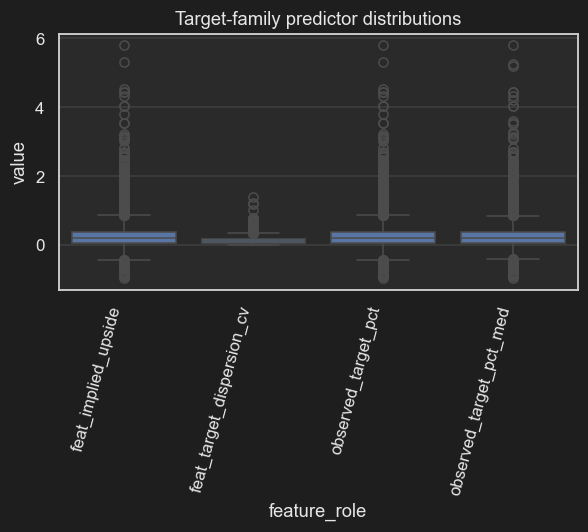

In [12]:
# 3.2 Visualise distribution of target-family predictors per category
#     Iterate feature_aliases for the 'target' feature_role and map them
#     onto price_target_df columns (the MV exposes columns by feature_alias).
rev_aliases = (
    summary_stats.loc[summary_stats['feature_role'] == 'target',
    'feature_alias']
    .dropna()
    .unique()
    .tolist()
)
rev_cols = [a for a in rev_aliases if a in price_target_df.columns
            and pd.api.types.is_numeric_dtype(price_target_df[a])]
if rev_cols:
    melted = price_target_df[rev_cols].melt(var_name='feature_role', value_name='value').dropna()
    fig, ax = plt.subplots(figsize=(min(14, 0.4 * len(rev_cols) + 4), 5))
    sns.boxplot(data=melted, x='feature_role', y='value', ax=ax, showfliers=True)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=75, ha='right')
    ax.set_title('Target-family predictor distributions')
    plt.tight_layout();
    plt.show()
else:
    print('No target-role predictors present in price_target_df.')


## 4. Build PyMC-Aligned Data Containers

Hierarchical Student-t regression on `observed_target_pct`, schema-aligned with `PriceTargetAchievement` (see `probabilistic_ml_model.pymc_models.PriceTargetModel`). The likelihood is a heavy-tailed Student-t on the analyst-implied upside (`observed_target_pct = target_pct_avg`), with the per-isin scale shrunk by `1 / sqrt(n_analysts)` so that broadly-covered names carry more weight. `pm.Data` container names mirror `pml.mv_pymc_price_target` columns (and therefore `vw_pymc_feature_catalogue.feature_alias`) so that `pm.set_data` round-trips against the live MV.

**Schema alignment with `pml.mv_pymc_price_target`.** The model coords now include every categorical column emitted by the materialized view (DDL columns `region`, `country`, `trading_country`, `exchange`, `unit`, `style_class`, `size_class`, `sector`, `industry`). Each coord is registered as a `pm.Model` dimension and as a `pm.Data('<coord>_idx', …, dims='isin')` integer-index container, so posterior predictive checks can be conditioned on any of them via `pm.set_data`. Hierarchical partial-pooling intercepts are attached to `sector`, `size_class`, and `style_class` (the highest-signal, lowest-cardinality coords); the remaining coords are available for downstream slicing without inflating the parameter count.


In [13]:
# 4.0  Filter rows with a usable response
model_df = price_target_df.loc[
    price_target_df['observed_target_pct'].notna() &
    price_target_df['n_analysts'].fillna(0).gt(0)
    ].copy().reset_index(drop=True)
print(f'Modelling rows (response present & n_analysts>0): {len(model_df)}')

# ---------------------------------------------------------------------------
# Categorical coords: every column tagged as `coord` in vw_pymc_feature_catalogue
# and present in pml.mv_pymc_price_target. Each becomes a model dimension with
# its own integer index array (`<coord>_idx`) and unique-label vector.
# ---------------------------------------------------------------------------
isin_labels = model_df['isin'].astype(str).values

CATEGORICAL_COORDS = [c for c in COORD_COLS
                      if c in model_df.columns and c not in ('isin', 'ticker')]
print(f'Categorical coords ({len(CATEGORICAL_COORDS)}): {CATEGORICAL_COORDS}')

coord_uniques = {}  # coord_name -> np.ndarray of unique labels
coord_idx = {}  # coord_name -> np.ndarray of int64 indices (len == n_obs)
for col in CATEGORICAL_COORDS:
    labels = model_df[col].fillna('Unknown').astype(str).values
    uniques, idx = np.unique(labels, return_inverse=True)
    coord_uniques[col] = uniques
    coord_idx[col] = idx.astype('int64')

# Back-compat aliases (legacy downstream cells expect `sector_*` symbols)
sector_uniques = coord_uniques['sector']
sector_idx = coord_idx['sector']
sector_labels = model_df['sector'].fillna('Unknown').astype(str).values


Modelling rows (response present & n_analysts>0): 6612
Categorical coords (9): ['country', 'exchange', 'industry', 'region', 'sector', 'size_class', 'style_class', 'trading_country', 'unit']


In [14]:
# 4.1  Predictor matrix — numeric feat_* with ≥70% coverage, capped at 8 features
num_pred_cols = [c for c in PREDICTOR_COLS if pd.api.types.is_numeric_dtype(model_df[c])]
coverage = model_df[num_pred_cols].notna().mean()
selected_predictors = coverage[coverage >= 0.70].sort_values(ascending=False).index.tolist()[:8]
print(f'Selected predictors ({len(selected_predictors)}): {selected_predictors}')

X_raw = model_df[selected_predictors].astype(float)
X_std = (X_raw - X_raw.mean()) / X_raw.std(ddof=0).replace(0, 1.0)
X = X_std.fillna(0.0).to_numpy()

# Response + precision-weight
y_target_pct = model_df['observed_target_pct'].astype(float).to_numpy()
n_analysts = model_df['n_analysts'].astype(int).clip(lower=1).to_numpy()


Selected predictors (5): ['last_price', 'feat_vol_3m', 'feat_analyst_rating', 'feat_ev_ebitda_ntm', 'feat_pe_ntm']


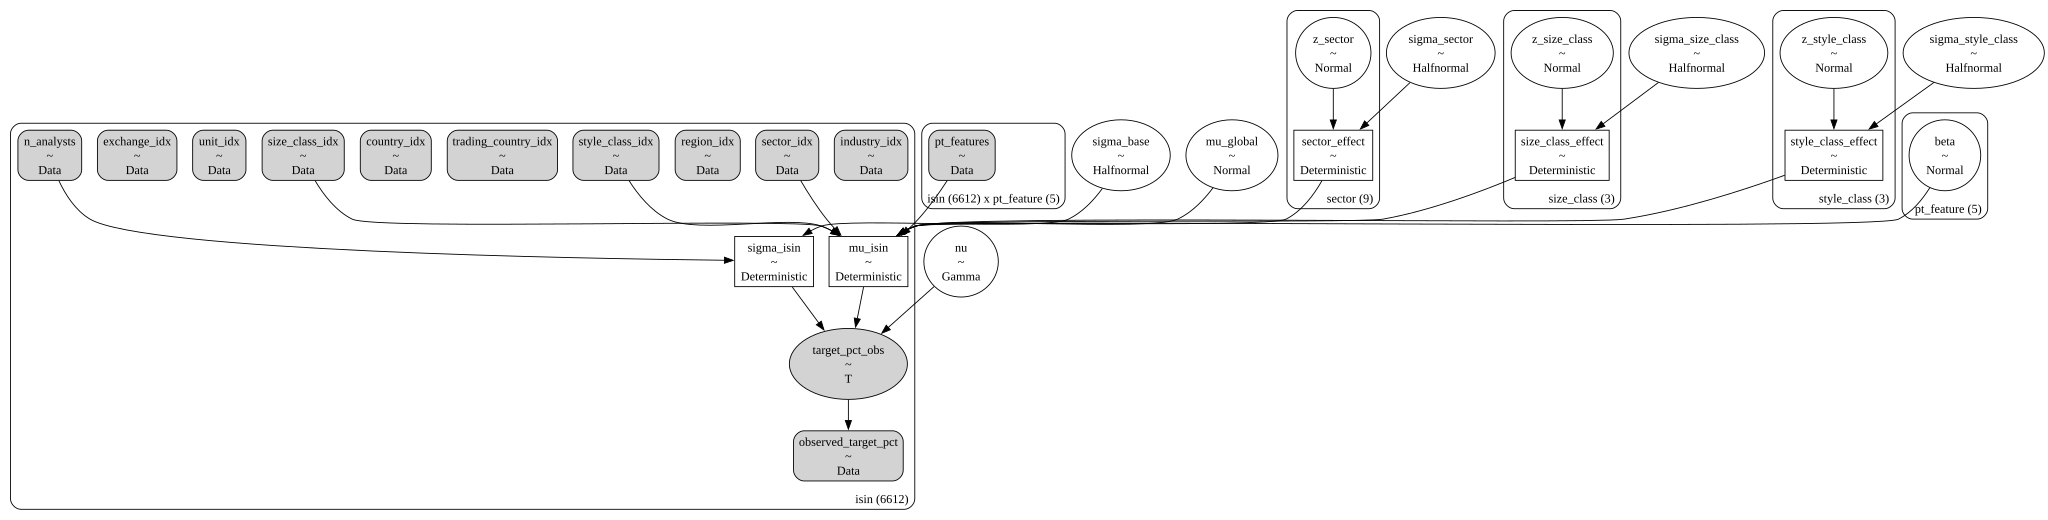

In [15]:
# 4.2  PyMC model — hierarchical Student-t on observed_target_pct
# Build the coords dict from all categorical columns exposed by
# pml.mv_pymc_price_target (DDL: region, country, trading_country, exchange,
# unit, style_class, size_class, sector, industry).
coords = {
    'isin': isin_labels,
    'pt_feature': selected_predictors,  # mirrors PriceTargetAchievement
}
for _c in CATEGORICAL_COORDS:
    coords[_c] = coord_uniques[_c]

# Group-effect coords with enough rows per level to inform a hierarchical
# Normal sector/size/style intercept. Other categorical columns remain available
# as model coords / pm.Data for downstream slicing and posterior conditioning.
GROUP_EFFECTS = [c for c in ('sector', 'size_class', 'style_class') if c in CATEGORICAL_COORDS]

with pm.Model(coords=coords) as price_target_model:
    # ----- pm.Data containers (names = MV aliases) -----
    observed_target_pct = pm.Data('observed_target_pct', y_target_pct, dims='isin')
    n_analysts_data = pm.Data('n_analysts', n_analysts, dims='isin')
    X_data = pm.Data('pt_features', X, dims=('isin', 'pt_feature'))

    # One pm.Data per coord-indexed group (sector_idx, industry_idx, ...)
    idx_data_vars = {}
    for col in CATEGORICAL_COORDS:
        idx_data_vars[col] = pm.Data(f'{col}_idx', coord_idx[col], dims='isin')

    # ----- Global intercept (%) -----
    mu_global = pm.Normal('mu_global', mu=0.0, sigma=10.0)

    # ----- Hierarchical group effects (non-centred Normal) -----
    group_effects = {}
    for col in GROUP_EFFECTS:
        sigma_g = pm.HalfNormal(f'sigma_{col}', sigma=10.0)
        z_g = pm.Normal(f'z_{col}', mu=0.0, sigma=1.0, dims=col)
        eff = pm.Deterministic(f'{col}_effect', sigma_g * z_g, dims=col)
        group_effects[col] = eff

    # ----- Predictor coefficients on standardised feat_* -----
    beta = pm.Normal('beta', mu=0.0, sigma=5.0, dims='pt_feature')

    # ----- Linear predictor on the % scale -----
    eta = mu_global + pt.dot(X_data, beta)
    for col in GROUP_EFFECTS:
        eta = eta + group_effects[col][idx_data_vars[col]]

    mu_isin = pm.Deterministic('mu_isin', eta, dims='isin')

    # ----- Precision weighted by analyst coverage -----
    sigma_base = pm.HalfNormal('sigma_base', sigma=25.0)
    sigma_isin = pm.Deterministic(
        'sigma_isin',
        sigma_base / pt.sqrt(pt.cast(n_analysts_data, 'floatX')),
        dims='isin',
    )

    # ----- Heavy-tailed analyst noise -----
    nu = pm.Gamma('nu', alpha=2.0, beta=0.1)  # ν > 0, mean 20

    pm.StudentT(
        'target_pct_obs',
        nu=nu, mu=mu_isin, sigma=sigma_isin,
        observed=observed_target_pct, dims='isin',
    )

pm.model_to_graphviz(price_target_model)

## 5. Prior Predictive Checks

Sample from the prior to verify that priors imply a plausible distribution of analyst implied upside (`observed_target_pct`) centred near zero with heavy-tailed coverage of the empirical distribution.


In [16]:
# 5.0  Prior predictive
with price_target_model:
    prior_idata = pm.sample_prior_predictive(
        draws=500, random_seed=RANDOM_SEED, return_inferencedata=True
    )
prior_idata


Sampling: [beta, mu_global, nu, sigma_base, sigma_sector, sigma_size_class, sigma_style_class, target_pct_obs, z_sector, z_size_class, z_style_class]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:             (chain: 1, draw: 500, style_class: 3, sector: 9,
│                                size_class: 3, isin: 6612, pt_feature: 5)
│       Coordinates:
│         * chain               (chain) int64 8B 0
│         * draw                (draw) int64 4kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
│         * style_class         (style_class) <U6 72B 'Core' 'Growth' 'Value'
│         * sector              (sector) <U22 792B 'Communication Services' ... 'Util...
│         * size_class          (size_class) <U9 108B 'Large Cap' 'Mid Cap' 'Small Cap'
│         * isin                (isin) <U12 317kB 'US02079K3059' ... 'GG00BG0KTL52'
│         * pt_feature          (pt_feature) <U19 380B 'last_price' ... 'feat_pe_ntm'
│       Data variables: (12/15)
│           sigma_size_class    (chain, draw) float64 4kB 0.408 12.92 ... 13.52 5.91
│           sigma_base          (chain, draw) float64 4kB 2.511 36.5 39.54 ... 8.2 22.91
│           style_class_effect  (chain, draw, style_class) float64 12kB 1.436 ... 1.901
│           sector_effect       (chain, draw, sector) float64 36kB -1.788 ... -19.61
│           size_class_effect   (chain, draw, size_class) float64 12kB 0.5118 ... -14.51
│           sigma_sector        (chain, draw) float64 4kB 1.084 4.138 ... 0.6492 11.54
│           ...                  ...
│           mu_global           (chain, draw) float64 4kB 17.99 -17.76 ... -12.07 -10.61
│           sigma_isin          (chain, draw, isin) float64 26MB 0.3449 1.775 ... 22.91
│           nu                  (chain, draw) float64 4kB 10.02 6.815 ... 27.88 28.93
│           mu_isin             (chain, draw, isin) float64 26MB 12.62 34.59 ... 5.396
│           sigma_style_class   (chain, draw) float64 4kB 3.433 16.61 ... 4.946 6.197
│           beta                (chain, draw, pt_feature) float64 20kB 0.1553 ... 2.683
│       Attributes:
│           created_at:                 2026-05-23T16:45:45.022747+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Dimensions:         (chain: 1, draw: 500, isin: 6612)
│       Coordinates:
│         * chain           (chain) int64 8B 0
│         * draw            (draw) int64 4kB 0 1 2 3 4 5 6 ... 494 495 496 497 498 499
│         * isin            (isin) <U12 317kB 'US02079K3059' ... 'GG00BG0KTL52'
│       Data variables:
│           target_pct_obs  (chain, draw, isin) float64 26MB 12.18 34.68 ... -37.62
│       Attributes:
│           created_at:                 2026-05-23T16:45:45.028024+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:         (isin: 6612)
│       Coordinates:
│         * isin            (isin) <U12 317kB 'US02079K3059' ... 'GG00BG0KTL52'
│       Data variables:
│           target_pct_obs  (isin) float64 53kB 0.1205 -0.2135 0.0994 ... 0.1888 0.8684
│       Attributes:
│           created_at:                 2026-05-23T16:45:45.030059+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                []
└── Group: /constant_data
        Dimensions:              (isin: 6612, pt_feature: 5)
        Coordinates:
          * isin                 (isin) <U12 317kB 'US02079K3059' ... 'GG00BG0KTL52'
          * pt_feature           (pt_feature) <U19 380B 'last_

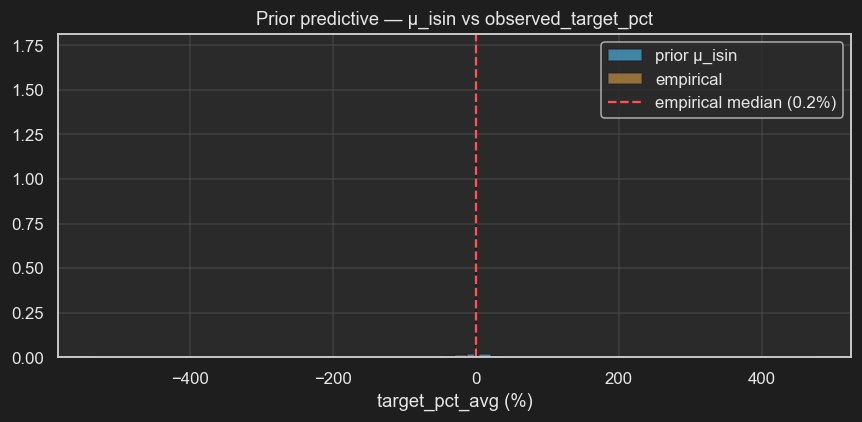

In [17]:
# 5.1  Prior on μ_isin vs empirical observed_target_pct
empirical = price_target_df['observed_target_pct'].dropna().to_numpy()
prior_mu = prior_idata.prior['mu_isin'].values.reshape(-1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(prior_mu, bins=60, density=True, alpha=0.6,
        color='#4FC3F7', edgecolor='#1e1e1e', label='prior μ_isin')
ax.hist(empirical, bins=60, density=True, alpha=0.5,
        color='#FFB74D', edgecolor='#1e1e1e', label='empirical')
ax.axvline(np.median(empirical), color='#FF5252', ls='--',
           label=f'empirical median ({np.median(empirical):.1f}%)')
ax.set_title('Prior predictive — μ_isin vs observed_target_pct')
ax.set_xlabel('target_pct_avg (%)')
ax.legend();
plt.tight_layout();
plt.show()


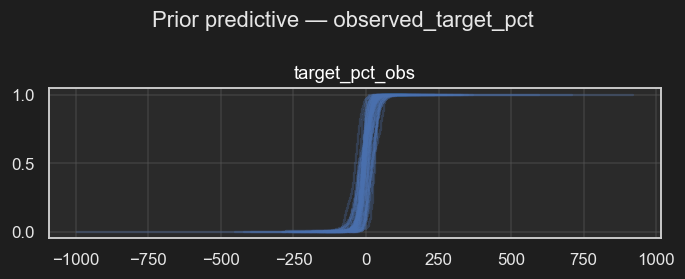

In [18]:
# 5.2  Prior predictive distribution of target_pct_obs
from arviz_plots import plot_ppc_dist

pc = plot_ppc_dist(
    prior_idata,
    group="prior_predictive",
    var_names=["target_pct_obs"],
    kind="ecdf",
    num_samples=50,
)
plt.suptitle("Prior predictive — observed_target_pct")
plt.tight_layout()
plt.show()

## 6. Posterior Inference (NUTS)

Short NUTS run for notebook responsiveness — tune/draws can be increased for a production fit. The trace below feeds the posterior predictive checks and diagnostics in §7–§8.


In [19]:
with price_target_model:
    idata = pm.sample(
        draws=500, tune=500, chains=2, cores=1,
        target_accept=0.9, random_seed=RANDOM_SEED,
        progressbar=False, return_inferencedata=True,
    )

# Merge prior / prior_predictive groups into the posterior idata.
# `add_groups` works for both legacy arviz.InferenceData and the
# arviz-base 1.x xarray.DataTree returned under PyMC 6 / ArviZ 1.x.
from probabilistic_ml_model._pymc_arviz_compat import extend_datatree

idata = extend_datatree(idata, prior_idata)
idata

NUTS[nutpie]: [mu_global, sigma_sector, z_sector, sigma_size_class, z_size_class, sigma_style_class, z_style_class, beta, sigma_base, nu]


<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:             (chain: 2, draw: 500, sector: 9, size_class: 3,
│                                style_class: 3, pt_feature: 5, isin: 6612)
│       Coordinates:
│         * chain               (chain) int64 16B 0 1
│         * draw                (draw) int64 4kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
│         * sector              (sector) object 72B 'Communication Services' ... 'Uti...
│         * size_class          (size_class) object 24B 'Large Cap' ... 'Small Cap'
│         * style_class         (style_class) object 24B 'Core' 'Growth' 'Value'
│         * pt_feature          (pt_feature) object 40B 'last_price' ... 'feat_pe_ntm'
│         * isin                (isin) object 53kB 'US02079K3059' ... 'GG00BG0KTL52'
│       Data variables: (12/15)
│           mu_global           (chain, draw) float64 8kB 0.1422 0.1285 ... 0.3051
│           z_sector            (chain, draw, sector) float64 72kB 1.037 ... -1.081
│           z_size_class        (chain, draw, size_class) float64 24kB 0.0818 ... -0....
│           z_style_class       (chain, draw, style_class) float64 24kB -0.1318 ... 0...
│           beta                (chain, draw, pt_feature) float64 40kB -0.001936 ... ...
│           sigma_sector        (chain, draw) float64 8kB 0.04764 0.05724 ... 0.06533
│           ...                  ...
│           nu                  (chain, draw) float64 8kB 2.339 2.358 ... 2.34 2.285
│           sector_effect       (chain, draw, sector) float64 72kB 0.04941 ... -0.07063
│           size_class_effect   (chain, draw, size_class) float64 24kB 0.005195 ... -...
│           style_class_effect  (chain, draw, style_class) float64 24kB -0.002632 ......
│           mu_isin             (chain, draw, isin) float64 53MB 0.2481 ... 0.4361
│           sigma_isin          (chain, draw, isin) float64 53MB 0.05353 ... 0.4008
│       Attributes:
│           created_at:                 2026-05-23T16:47:03.123018+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.1.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          nutpie
│           inference_library_version:  0.16.10
│           sampling_time:              64.51873111724854
│           tuning_steps:               500
├── Group: /sample_stats
│       Dimensions:                   (chain: 2, draw: 500)
│       Coordinates:
│         * chain                     (chain) int64 16B 0 1
│         * draw                      (draw) int64 4kB 0 1 2 3 4 ... 495 496 497 498 499
│       Data variables: (12/20)
│           depth                     (chain, draw) uint64 8kB 7 7 6 6 5 6 ... 8 6 7 8 6
│           maxdepth_reached          (chain, draw) bool 1kB False False ... False False
│           step_size                 (chain, draw) float64 8kB 0.1157 ... 0.08165
│           transformation_update_id  (chain, draw) int64 8kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           step_size_bar             (chain, draw) float64 8kB 0.1231 ... 0.08923
│           mean_tree_accept          (chain, draw) float64 8kB 0.957 0.9888 ... 0.9116
│           ...                        ...
│           fisher_distance           (chain, draw) float64 8kB 141.1 213.5 ... 408.9
│           transformation_index      (chain, draw) int64 8kB 423 423 423 ... 422 422
│           diverging                 (chain, draw) bool 1kB False False ... False False
│           divergence_draw           (chain, draw) uint64 8kB 0 0 0 0 0 0 ... 0 0 0 0 0
│           divergence_message        (chain, draw) object 8kB nan nan nan ... nan nan
│           divergence_energy_error   (chain, draw) float64 8kB nan nan nan ... nan nan
│       Attributes:
│           created_at:                  2026-05-23T16:47:03.089037+00:00
│           creation_library:            ArviZ
│           creation_library_version:    1.1.0
│           creation_library_language:   Python


## 7. Posterior Predictive Checks

Compare the predictive distribution of `observed_target_pct` (analyst implied upside) against the observed sample. A well-calibrated Student-t regression should cover the empirical density including its tails.


Sampling: [target_pct_obs]


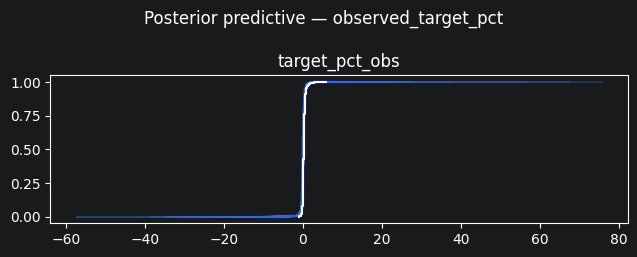

In [20]:
with price_target_model:
    pm.sample_posterior_predictive(
        idata, extend_inferencedata=True,
        random_seed=RANDOM_SEED, progressbar=False,
    )

from arviz_plots import plot_ppc_dist

pc = plot_ppc_dist(
    idata,
    group="posterior_predictive",
    var_names=["target_pct_obs"],
    kind="ecdf",
    num_samples=80,
)
plt.suptitle("Posterior predictive — observed_target_pct")
plt.tight_layout()
plt.show()


In [21]:
# 7.1 Posterior sector-mean μ vs empirical sector target_pct_avg
import pandas as pd

sector_agg = (
    model_df.groupby('sector', as_index=False)
    .agg(empirical_target_pct=('observed_target_pct', 'mean'),
         n_obs=('isin', 'size'))
    .sort_values('sector').reset_index(drop=True)
)

# Note: the model defines the hierarchical sector intercept as
# pm.Deterministic('sector_effect', sigma_sector * z_sector, dims='sector').
# There is no 'alpha_sector' variable in idata.posterior.
post_sector_effect = (
    idata.posterior['sector_effect']
    .mean(dim=('chain', 'draw'))
    .to_pandas()
    .rename('posterior_sector_effect')
    .reset_index()
)

by_sector = sector_agg.merge(post_sector_effect, on='sector', how='left')
print(by_sector)


                   sector  empirical_target_pct  n_obs  \
0  Communication Services              0.292056    356   
1  Consumer Discretionary              0.309960    886   
2        Consumer Staples              0.232860    504   
3                  Energy              0.198969    372   
4             Health Care              0.517670    849   
5             Industrials              0.206112   1506   
6  Information Technology              0.157926   1070   
7               Materials              0.271709    794   
8               Utilities              0.139948    275   

   posterior_sector_effect  
0                 0.036370  
1                 0.047374  
2                 0.030303  
3                -0.072021  
4                 0.080724  
5                -0.011162  
6                -0.061231  
7                -0.004378  
8                -0.048044  


## 8. MCMC Diagnostics

Convergence and sampler health: R-hat, ESS, divergences, trace plots, forest plot of predictor coefficients, and an ECDF of `p` — aligned with the ArviZ 1.0 diagnostic suite used in `probabilistic_ml_model.visualizations.arviz_diagnostics`.


In [22]:
# 8.1 R-hat and ESS summary for all tracked variables
# Discover which requested variables actually exist in the posterior AND have
# non-zero size. This guards against e.g. `beta` being declared with an empty
# `earnings_feature` coord when no predictors were selected.
posterior = idata.posterior
requested = ['mu_global', 'sigma_sector', 'sector_effect',
             'beta', 'sigma_base', 'nu']

available, skipped = [], []
for v in requested:
    if v not in posterior.data_vars:
        skipped.append((v, 'not in posterior'))
        continue
    da = posterior[v]
    # Sample dims are chain/draw — any other dim of size 0 makes summary fail.
    non_sample_sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
    if any(s == 0 for s in non_sample_sizes):
        skipped.append((v, f'empty dim(s): {dict(da.sizes)}'))
        continue
    available.append(v)

if skipped:
    print('Skipping variables:')
    for name, reason in skipped:
        print(f'  - {name}: {reason}')

if not available:
    raise RuntimeError('No non-empty variables to summarise. '
                       'Check that the model actually has free parameters.')

summary = az.summary(idata, var_names=available, round_to=4)
summary.sort_values('r_hat', ascending=False).head(20)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_global,0.1910,0.0676,0.0843,0.2866,106.5810,171.4123,1.0240,0.0070,0.0077
sigma_sector,0.0637,0.0210,0.0386,0.1055,349.1417,411.9017,1.0196,0.0011,0.0012
beta[feat_pe_ntm],-0.0352,0.0053,-0.0439,-0.0263,958.0211,769.5268,1.0045,0.0002,0.0001
nu,2.2861,0.0796,2.1576,2.4127,985.5904,696.7602,1.0037,0.0025,0.0019
sector_effect[Materials],-0.0044,0.0224,-0.0385,0.0328,398.2316,387.3280,1.0031,0.0011,0.0010
sector_effect[Consumer Discretionary],0.0474,0.0225,0.0134,0.0828,389.2987,399.5654,1.0030,0.0012,0.0010
sector_effect[Energy],-0.0720,0.0228,-0.1079,-0.0341,428.1174,370.7741,1.0030,0.0011,0.0009
sector_effect[Industrials],-0.0112,0.0223,-0.0451,0.0252,417.5820,446.4031,1.0028,0.0011,0.0010
sector_effect[Consumer Staples],0.0303,0.0226,-0.0044,0.0661,403.6648,453.3641,1.0026,0.0011,0.0010
sector_effect[Health Care],0.0807,0.0227,0.0462,0.1170,416.6872,491.9006,1.0024,0.0011,0.0009


In [23]:
# 8.2 Divergences and sampler stats
n_div = int(idata.sample_stats['diverging'].sum())


# Drop zero-sized variables before R-hat / ESS aggregation.
def _non_empty_vars(ds):
    keep = []
    for name, da in ds.data_vars.items():
        sizes = [da.sizes[d] for d in da.dims if d not in ('chain', 'draw')]
        if all(s > 0 for s in sizes):
            keep.append(name)
    return keep


# Get the underlying Dataset from the DataTree node
posterior_tree = idata.posterior
posterior = posterior_tree.dataset if hasattr(posterior_tree, "dataset") else posterior_tree.to_dataset()

keep_vars = _non_empty_vars(posterior)
rhat_ds = az.rhat(posterior[keep_vars])
ess_ds = az.ess(posterior[keep_vars], method='bulk')

max_rhat = float(rhat_ds.to_array().max())
min_ess = float(ess_ds.to_array().min())

print(f'Divergences: {n_div}')
print(f'Max R-hat  : {max_rhat:.4f}  (target < 1.01)')
print(f'Min ESS    : {min_ess:.1f}    (target > 400)')

Divergences: 3
Max R-hat  : 1.0240  (target < 1.01)
Min ESS    : 106.6    (target > 400)


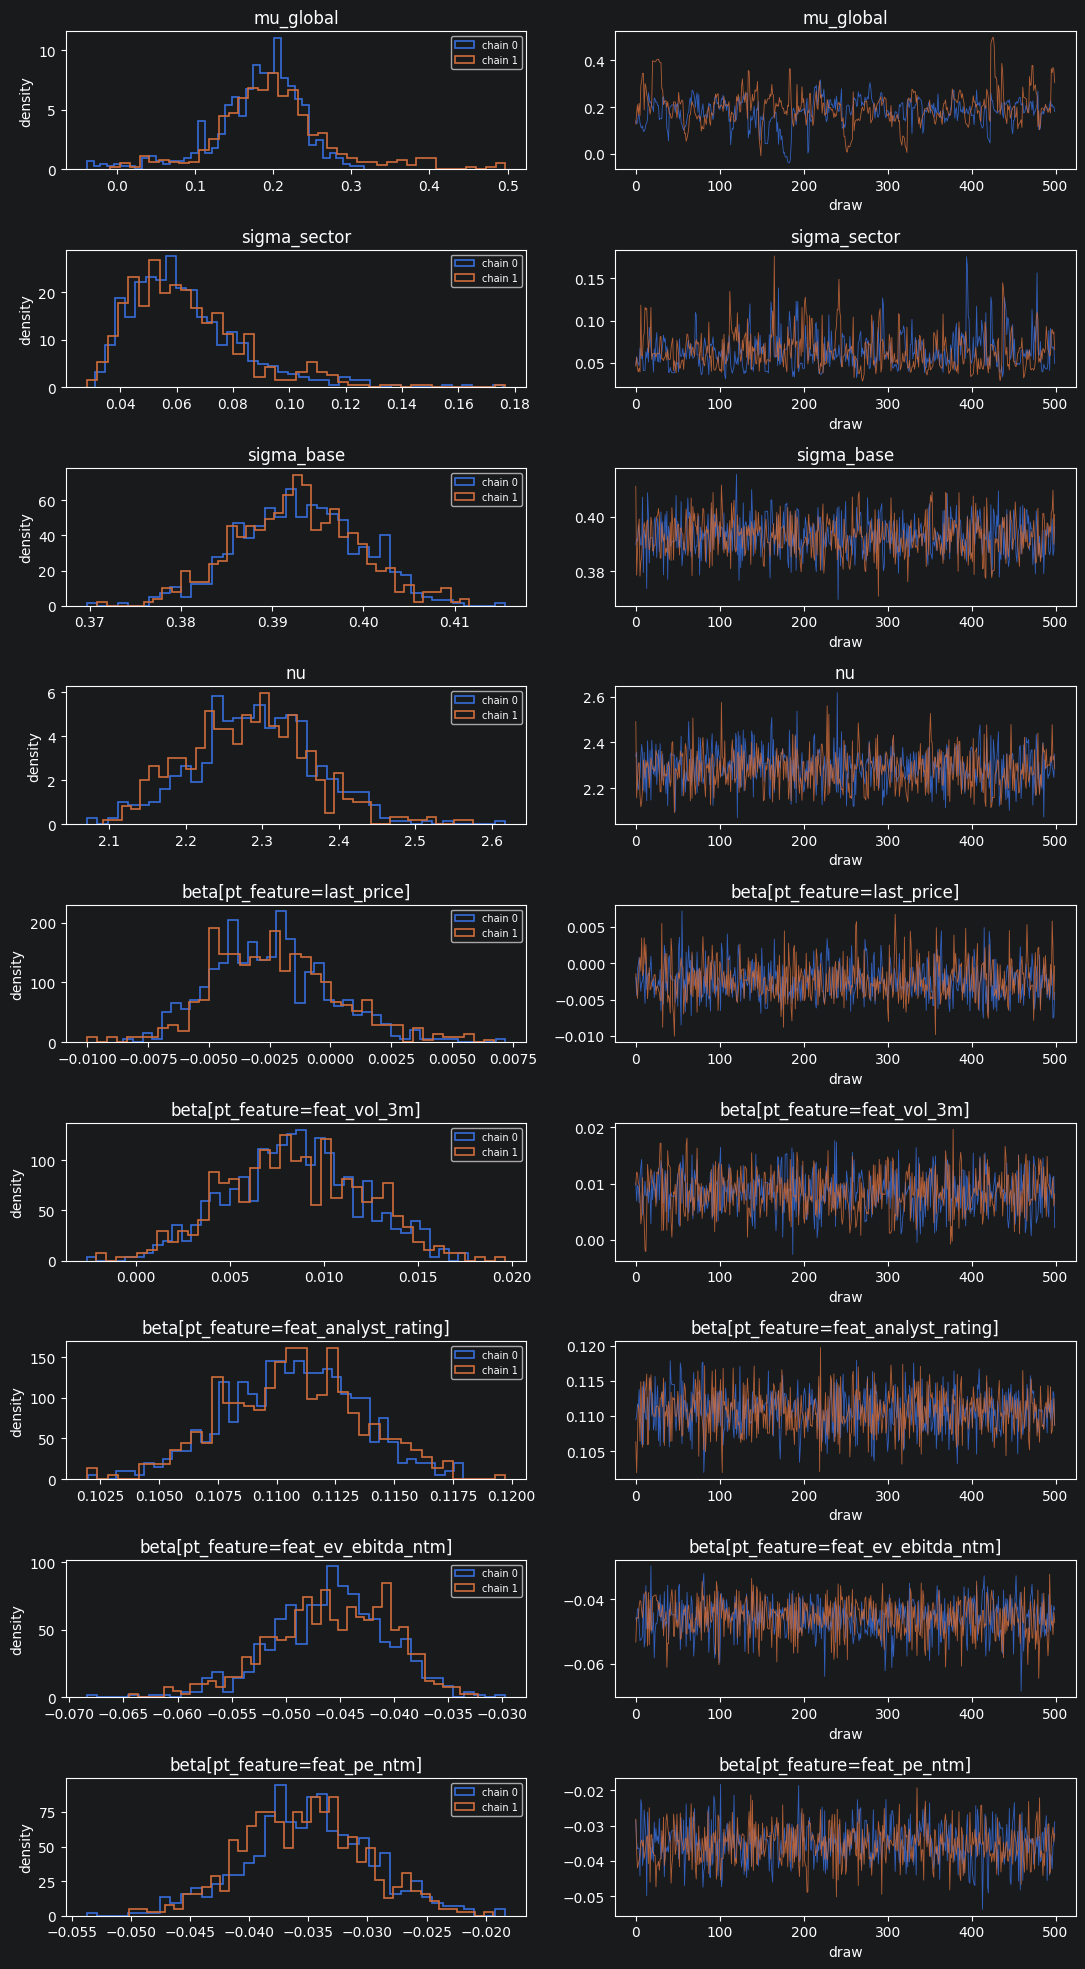

In [24]:
# 8.3 Trace + density plots for the key parameters (manual, backend-agnostic).
# We bypass az.plot_trace because arviz_plots' default aesthetic builder
# raises "cannot reshape array of size 6 into shape (2,)" when only scalar
# parameters are passed. Drawing from idata.posterior directly is robust.

import numpy as np
import matplotlib.pyplot as plt

trace_vars = [v for v in ('mu_global', 'sigma_sector', 'sigma_base', 'nu',
                          'beta', 'alpha_sector')
              if v in available]


def _iter_param_slices(da):
    """Yield (label_suffix, 2D array of shape (chain, draw)) for each scalar
    slice of a posterior DataArray. Works for scalar params (no extra dims)
    and for vector params (one extra dim, e.g. 'sector')."""
    extra_dims = [d for d in da.dims if d not in ('chain', 'draw')]
    if not extra_dims:
        yield '', da.values
        return
    # Flatten any extra dims into a product of coordinate labels.
    stacked = da.stack(_extra=extra_dims)
    for i in range(stacked.sizes['_extra']):
        sl = stacked.isel(_extra=i)
        # Build a readable suffix from coord values.
        coord_bits = []
        for d in extra_dims:
            val = sl.coords[d].values.item() if d in sl.coords else i
            coord_bits.append(f"{d}={val}")
        yield '[' + ', '.join(coord_bits) + ']', sl.values  # shape (chain, draw)


if trace_vars:
    posterior = idata.posterior
    # Build the row list first so we know the figure height.
    rows = []
    for v in trace_vars:
        if v not in posterior:
            continue
        da = posterior[v]
        # Skip variables with any empty dim (e.g. beta with earnings_feature=0).
        if any(da.sizes[d] == 0 for d in da.dims):
            continue
        for suffix, arr in _iter_param_slices(da):
            rows.append((f"{v}{suffix}", arr))

    if not rows:
        print('No non-empty posterior variables to plot.')
    else:
        n = len(rows)
        fig, axes = plt.subplots(n, 2, figsize=(11, 2.2 * n), squeeze=False)
        for i, (label, arr) in enumerate(rows):
            ax_density, ax_trace = axes[i, 0], axes[i, 1]
            n_chains = arr.shape[0]
            # Left panel: per-chain KDE-style histogram.
            for c in range(n_chains):
                vals = arr[c]
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue
                ax_density.hist(vals, bins=40, density=True,
                                histtype='step', linewidth=1.2,
                                label=f'chain {c}')
            ax_density.set_title(label)
            ax_density.set_ylabel('density')
            if n_chains > 1:
                ax_density.legend(fontsize=7, loc='best')
            # Right panel: trace.
            for c in range(n_chains):
                ax_trace.plot(arr[c], linewidth=0.6, alpha=0.85,
                              label=f'chain {c}')
            ax_trace.set_title(label)
            ax_trace.set_xlabel('draw')
        plt.tight_layout()
        plt.show()
else:
    print('No trace-eligible variables available.')


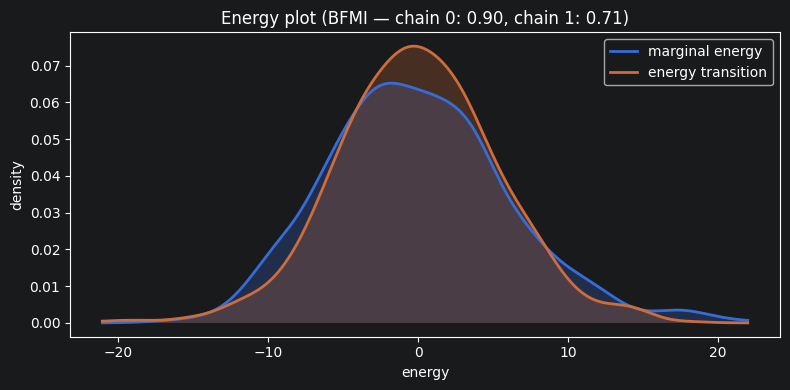

In [25]:
# 8.4 Energy plot (NUTS health) + posterior ECDF of p

# Robustly get groups for both InferenceData and DataTree
_groups_attr = getattr(idata, "groups", None)
if callable(_groups_attr):
    _groups = _groups_attr()  # classic arviz.InferenceData
else:
    _groups = tuple(_groups_attr) if _groups_attr is not None else ()  # xarray.DataTree

# DataTree group names start with '/', InferenceData uses plain names — normalize:
_group_names = {g.lstrip("/").split("/")[-1] for g in _groups}

if "sample_stats" in _group_names and "energy" in idata.sample_stats.data_vars:
    import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# DataTree group names start with '/', InferenceData uses plain names — normalize:
_group_names = {g.lstrip("/").split("/")[-1] for g in _groups}

if "sample_stats" in _group_names and "energy" in idata.sample_stats.data_vars:
    # Extract energy as a clean (chain, draw) array — drop any stray coords/dims
    energy = idata.sample_stats["energy"]
    # Keep only chain & draw dims, squeeze anything else
    extra_dims = [d for d in energy.dims if d not in ("chain", "draw")]
    if extra_dims:
        energy = energy.mean(dim=extra_dims)  # collapse any spurious dims safely
    e = energy.values  # shape (chain, draw)

    # Marginal energy: E itself (centered); Transition energy: diff along draws
    marginal = (e - e.mean()).ravel()
    transition = np.diff(e, axis=1).ravel()
    # Center transition the same way marginal is centered
    transition = transition - transition.mean() + marginal.mean()

    # BFMI per chain (Betancourt 2016)
    bfmi = np.array([
        np.sum(np.diff(e[c]) ** 2) / np.sum((e[c] - e[c].mean()) ** 2)
        for c in range(e.shape[0])
    ])

    fig, ax = plt.subplots(figsize=(8, 4))
    grid = np.linspace(min(marginal.min(), transition.min()),
                       max(marginal.max(), transition.max()), 400)

    kde_m = gaussian_kde(marginal)
    kde_t = gaussian_kde(transition)
    ax.plot(grid, kde_m(grid), label="marginal energy", lw=2)
    ax.plot(grid, kde_t(grid), label="energy transition", lw=2)
    ax.fill_between(grid, kde_m(grid), alpha=0.25)
    ax.fill_between(grid, kde_t(grid), alpha=0.25)

    bfmi_str = ", ".join(f"chain {i}: {b:.2f}" for i, b in enumerate(bfmi))
    ax.set_title(f"Energy plot (BFMI — {bfmi_str})")
    ax.set_xlabel("energy")
    ax.set_ylabel("density")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("sample_stats.energy not available — skipping energy plot.")


### Summary

- §2 — EDA over `pml.mv_pymc_price_target` columns using `vw_pymc_feature_catalogue` (`pymc_role` / `feature_role` / `feature_alias`). Classification coords (`region, country, trading_country, exchange, unit, style_class, size_class, sector, industry`) profiled.
- §3 — per-column summary statistics merged with the catalogue, rolled up by `(pymc_role, feature_role, category)`; analyst-sentiment / valuation predictors visualised.
- §4 — hierarchical Student-t PyMC model with `pm.Data` containers named after MV aliases (`observed_target_pct`, `n_analysts`, `sector_idx`, `pt_features`), schema-aligned with `PriceTargetAchievement`.
- §5 / §7 — prior and posterior predictive checks against observed `target_pct_avg`.
- §8 — R-hat / ESS / divergences / trace / energy diagnostics on `mu_global, sigma_sector, alpha_sector, beta, sigma_base, nu`.